In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# LOADING THE DATA

df = pd.read_csv('/Users/manurajgoel/Desktop/MLPRACTICAL/COURSE MODELS/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
# to check shape of the data
df.shape

(200, 2)

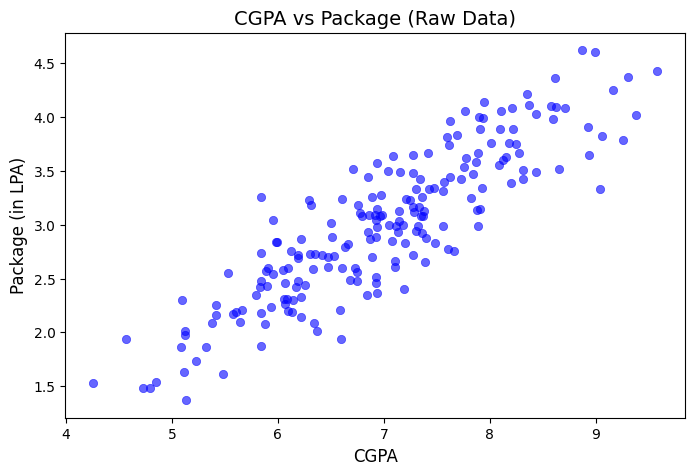

In [4]:
plt.figure(figsize= (8,5))
plt.scatter(df['cgpa'], df['package'], color='blue', alpha=0.6, linewidth = 0.5)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Package (in LPA)', fontsize=12)
plt.title('CGPA vs Package (Raw Data)', fontsize=14)
plt.show()

In [5]:
# DEFINING INPUT(X) AND OUTPUT(y) features

X = df[['cgpa']]  # 2d (n,1)
y = df['package'] # 1d (n,)

# X is taken as 2D as it is a INPUT feature 
# Y is taken as 1D as it is a OUTPUT value
# .reshape() as sklearn needs 2D input

In [6]:
# splitting data into TRAIN and TEST

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

'''
X_train, y_train -> Data to learn from
X_test, y_test  -> Data to evaluate on
test_size=0.2 (20% test, 80% train)
random_state -> Same split every time we run 

'''

'\nX_train, y_train -> Data to learn from\nX_test, y_test  -> Data to evaluate on\ntest_size=0.2 (20% test, 80% train)\nrandom_state -> Same split every time we run \n\n'

In [7]:
# creating a LINEAR REGRESSION model

model = LinearRegression()

# this creates y = mx+c

In [8]:
# TRAINING THE MODEL

model.fit(X_train, y_train)

m = model.coef_
b = model.intercept_

print("m (slope) : ", m)
print("b (intercept) : ", b)

# Finds best m and b
# Minimizes error between: actual y and predicted y
# Uses optimized math (Normal Equation / solver)


m (slope) :  [0.57425647]
b (intercept) :  -1.02700693745421


In [9]:
# MAKING PREDICTION / OUPUT OF MODEL

y_pred = model.predict(X_test)

# print(y_pred)
# y(pred) = mx+b

In [10]:
# EVALUATING THE MODEL

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean Squared Error", mse)
print("Root Mean Squared Error", rmse)
print("Mean Absolute Error", mae)
print("R2 Score:", r2)


# smaller MSE/RMSE -> better predictions
# R^2 close to 1 -> good model

Mean Squared Error 0.08417638361329657
Root Mean Squared Error 0.2901316659954521
Mean Absolute Error 0.23150985393278373
R2 Score: 0.7730984312051673


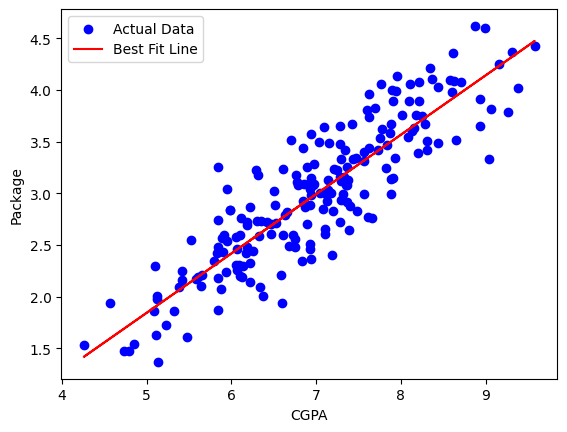

In [11]:
# BEST FIT LINE

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(X, model.predict(X), color='red', label='Best Fit Line')

# x = x-axis value
# model.predict(x) = Y axis predicted values

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.legend()
plt.show()

In [12]:
new_cgpa = pd.DataFrame({'cgpa': [5.12]})
predicted_package = model.predict(new_cgpa)
print("Predicted Package:", predicted_package[0])

Predicted Package: 1.9131862027796185
